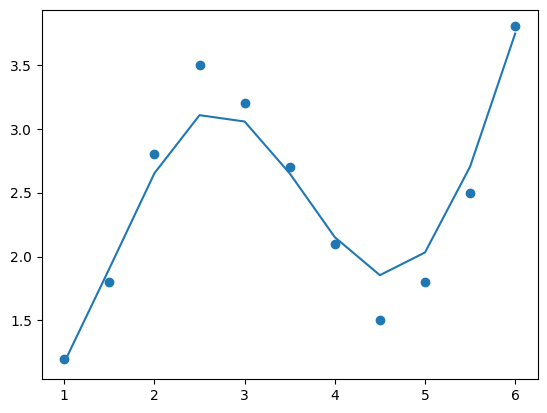

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def lwr(X, y, k):
    m = len(X)
    ypred = np.zeros(m)
    for i in range(m):
        # Calculate Gaussian weights for the current point
        w = np.exp(-np.sum((X - X[i])**2, axis=1)/(2*k**2))
        W = np.diag(w)
        # Solve the Weighted Normal Equation
        theta = np.linalg.pinv(X.T @ W @ X) @ X.T @ W @ y
        ypred[i] = X[i] @ theta
    return ypred

# Data preparation
data = pd.read_csv('data.csv')
# Column 'colA' is the feature, 'colB' is the target
X = np.c_[np.ones(len(data)), data.colA]
y = data.colB.values

# Execute LWR with k=0.5
ypred = lwr(X, y, 0.5)

# Sort indices for smooth plotting
idx = X[:,1].argsort()

# Visualization
plt.scatter(data.colA, data.colB)
plt.plot(X[idx,1], ypred[idx])
plt.show()